In [1]:
from pathlib import Path 
import os 
import sys
sys.path.insert(0, "../../../../../shared_utils")
from experiment_utils import manual_filtering

import matplotlib.pyplot as plt 
import scanpy as sc
import numpy as np 
import pandas as pd
import scipy as sp 
import seaborn as sns
from tqdm import tqdm 
import copy
import math
import yaml
import fpsample

## Read annotation file

In [2]:
# Annotation file for protocols 
ANNOTATION_CFG_FILE = "../../../../../inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

ANNOTATION_CFG_FILE_BOUNDS = "../../../../../inverse/loss_guidance/config/constraints/default_all_cols.yaml"
with open(ANNOTATION_CFG_FILE_BOUNDS, "r") as fb:
    annotation_cfg_bound = yaml.safe_load(fb)
ubound_dict, lbound_dict = annotation_cfg_bound["ubound_dict"],  annotation_cfg_bound["lbound_dict"]

# Collect per parameter bounds 
bounds = {}
for param in lbound_dict:
    bounds[param] = (lbound_dict[param], ubound_dict[param])

### Collect optimized samples 

In [3]:
path_to_results = Path("../../../../../project_folder/output/inverse/loss_guidance/raw_data/")
paths = os.listdir(path_to_results)

In [4]:
cell_types = ["CD14-Mono",
              "CyclingProgenitor*",
              "DCs-CD14",
              "Early_Pro-B", 
              "EosBasoMastPre", 
              "EryPro",
              "GMP-Neutro:CD16-Mono",
              "HSCs",
              "MgkPro",
              "Pro-B"]

In [5]:
pure_cell_type_solution_dict = {cell_type: [] 
                                for cell_type in cell_types
                               }

for experiment_folder in tqdm(paths):
    # Only consider pure populations 
    if "pure" in experiment_folder:
        cell_type_file_paths = path_to_results / experiment_folder
        # For all cell types 
        for cell_type in os.listdir(cell_type_file_paths):
            config_exp_folders = cell_type_file_paths / cell_type
            # For all the experiments in the folders 
            for config_exp_folder in os.listdir(config_exp_folders):
                # Be sure candidates are there 
                if "candidates.csv" in os.listdir(config_exp_folders / config_exp_folder):
                    path = config_exp_folders / config_exp_folder / "candidates.csv"
                    candidate_with_uncertainty_df = pd.read_csv(path)
                    candidate_with_uncertainty_df["run_name"] = [file.split("/")[-1] for file in candidate_with_uncertainty_df["cfg:paths:dump_dir"]]
                    pure_cell_type_solution_dict[cell_type].append(candidate_with_uncertainty_df)
                    
                    # uncertainty_path = config_exp_folders / config_exp_folder / "uncertainty_annotation" / "candidates_with_uncertainties.csv"
                    # # Be sure uncertainty annotation exists 
                    # if uncertainty_path.exists():
                    #     candidate_with_uncertainty_df = pd.read_csv(uncertainty_path)
                    #     candidate_with_uncertainty_df["run_name"] = [file.split("/")[-1] for file in candidate_with_uncertainty_df["cfg:paths:dump_dir"]]
                    #     pure_cell_type_solution_dict[cell_type].append(candidate_with_uncertainty_df)

100%|██████████| 6/6 [06:11<00:00, 61.83s/it]


In [6]:
# Concatenate data frame 
pure_cell_type_solution_dict_concat = {
    key: pd.concat(val, axis=0) for key, val in pure_cell_type_solution_dict.items()
}

In [7]:
for col in pure_cell_type_solution_dict_concat["HSCs"].columns:
    print(col)

sample_id
gm-csf_[ng_ml]
tpo_[ng_ml]
sr1_[nm]
um171_[nm]
um729_[µm]
scf_[ng_ml]
butyzamide_[nm]
retinoic_acid_[µm]
ldl_[ng_ml]
il3_[ng_ml]
o2_[%]
days_of_culture
gm-csf_[ng_ml]:rescaled
tpo_[ng_ml]:rescaled
sr1_[nm]:rescaled
um171_[nm]:rescaled
um729_[µm]:rescaled
scf_[ng_ml]:rescaled
butyzamide_[nm]:rescaled
retinoic_acid_[µm]:rescaled
ldl_[ng_ml]:rescaled
il3_[ng_ml]:rescaled
o2_[%]:rescaled
days_of_culture:rescaled
loss
CD14-Mono_prop
CD49c-Myeloid_prop
CyclingProgenitor*_prop
DCs-CD14_prop
EarlyGMP_prop
Early_Pro-B_prop
EosBasoMastPre_prop
EosBasoMastPre_2_prop
EryPro_prop
GMP-Cycle_prop
GMP-Neutro_prop
GMP-Neutro/CD16-Mono_prop
HSCs_prop
MEP_prop
MLP_prop
MPP_prop
MgkPro_prop
Pro-B_prop
pDCs/cDCs_prop
cfg:annotation:protocol_columns
cfg:annotation:protocol_obs_key_added
cfg:annotation:protocol_sep
cfg:annotation:one_hot_uns_key_added
cfg:annotation:protocol_obsm_key
cfg:annotation:scatter_columns
cfg:annotation:base_sample_rep
cfg:annotation:scatter_obsm_key
cfg:annotation:concat_

### Initialize targets

In [8]:
# Cell type fractions
celltype_fraction = {cell_type.replace(":", "/"): 0.15 for cell_type in cell_types}

columns_of_interest = [
    'gm-csf_[ng_ml]',
    'tpo_[ng_ml]',
    'sr1_[nm]',
    'um171_[nm]',
    'um729_[µm]',
    'scf_[ng_ml]',
    'butyzamide_[nm]',
    'retinoic_acid_[µm]',
    'ldl_[ng_ml]',
    'il3_[ng_ml]',
    'o2_[%]',
    'days_of_culture',
    'run_name',
    "cfg:constraints:c_scheduler_kwargs:t_warmup",
    "cfg:constraints:c_scheduler_kwargs:vmin",
    "cfg:constraints:c_scheduler_kwargs:vmax",
    # "loss", 
    # "target_ct_loss_std",
    # "target_ct_loss_mean",
    # "ct_prop_total_variance",
    # "exploitation_score",
    # "exploration_score",
    # "weighted_uncertainty_score",
    # "metric_response_surface", 
    # "indices",
    # "losses",
    # "acq_values"
]

In [9]:
for cell_type in cell_types:
    cell_type_safe_inverted = cell_type.replace(":", "/")
    print(f"{cell_type} proportion", pure_cell_type_solution_dict_concat[cell_type][f"{cell_type_safe_inverted}_prop"].max())

CD14-Mono proportion 0.9573434
CyclingProgenitor* proportion 1.0
DCs-CD14 proportion 0.8569238
Early_Pro-B proportion 0.9480131
EosBasoMastPre proportion 0.95440084
EryPro proportion 0.90798944
GMP-Neutro:CD16-Mono proportion 0.96039265
HSCs proportion 0.9861057
MgkPro proportion 0.8535928
Pro-B proportion 0.9024654


### Filter values

In [10]:
# Collect filtered and annotated data frames 
filtered_df, annotated_df = manual_filtering(
    df_dict=pure_cell_type_solution_dict_concat,
    bounds=bounds,
    columns_to_keep=columns_of_interest, 
    celltype_fraction=celltype_fraction,
    margin_frac_bounds=0.5, 
    protocol_cols=protocol_cols
)

In [11]:
# Filtered and unfiltered solutions 
for ct in filtered_df:
    print(f"Filtered {ct} number of solutions:", filtered_df[ct].shape[0])
    print(f"Unfiltered {ct} number of solutions:", pure_cell_type_solution_dict_concat[ct].shape[0], "\n")

Filtered CD14-Mono number of solutions: 14783
Unfiltered CD14-Mono number of solutions: 43000 

Filtered CyclingProgenitor* number of solutions: 9554
Unfiltered CyclingProgenitor* number of solutions: 37900 

Filtered DCs-CD14 number of solutions: 2157
Unfiltered DCs-CD14 number of solutions: 43100 

Filtered Early_Pro-B number of solutions: 97
Unfiltered Early_Pro-B number of solutions: 48100 

Filtered EosBasoMastPre number of solutions: 8769
Unfiltered EosBasoMastPre number of solutions: 48100 

Filtered EryPro number of solutions: 4275
Unfiltered EryPro number of solutions: 43100 

Filtered GMP-Neutro:CD16-Mono number of solutions: 7622
Unfiltered GMP-Neutro:CD16-Mono number of solutions: 30400 

Filtered HSCs number of solutions: 57
Unfiltered HSCs number of solutions: 33100 

Filtered MgkPro number of solutions: 1219
Unfiltered MgkPro number of solutions: 65600 

Filtered Pro-B number of solutions: 22
Unfiltered Pro-B number of solutions: 38100 



## Only keep solutions of correct cell types and analyze 

In [12]:
filtered_df = {key:val for key,val in filtered_df.items() if filtered_df[key].shape[0]>0 }

In [13]:
for cell_type in cell_types:
    cell_type_safe_revert = cell_type.replace(":", "/")

    print(f"{cell_type} proportion", filtered_df[cell_type][f"{cell_type_safe_revert}_prop"].max())

CD14-Mono proportion 0.9250439
CyclingProgenitor* proportion 0.9888993
DCs-CD14 proportion 0.64439416
Early_Pro-B proportion 0.41801026
EosBasoMastPre proportion 0.6808073
EryPro proportion 0.5657115
GMP-Neutro:CD16-Mono proportion 0.929622
HSCs proportion 0.3379116
MgkPro proportion 0.61231595
Pro-B proportion 0.22816448


/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


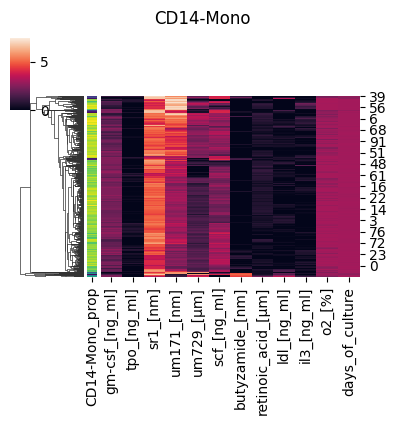

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


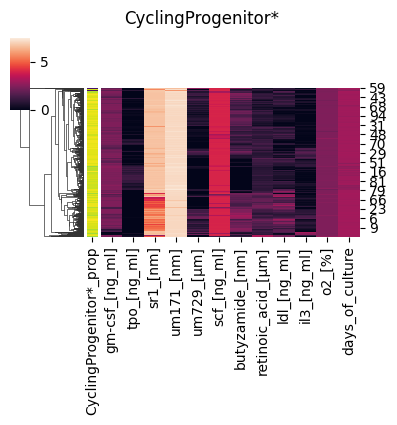

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


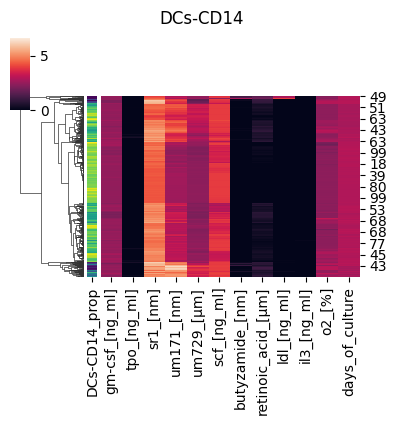

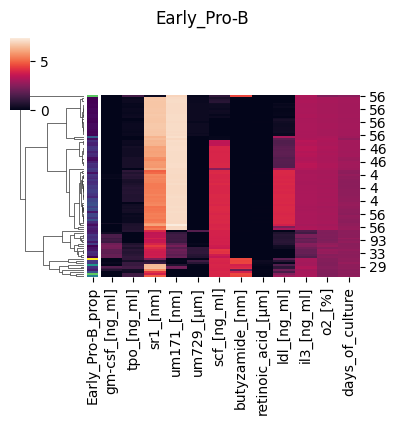

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


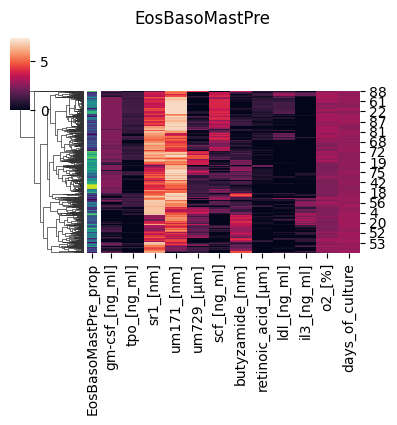

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


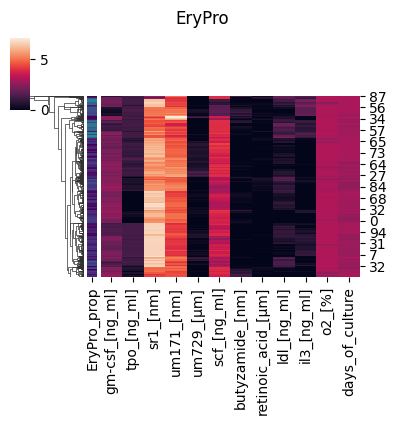

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


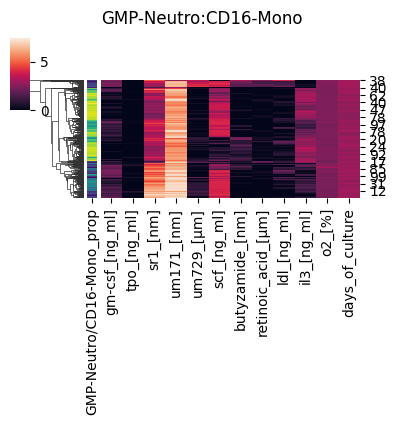

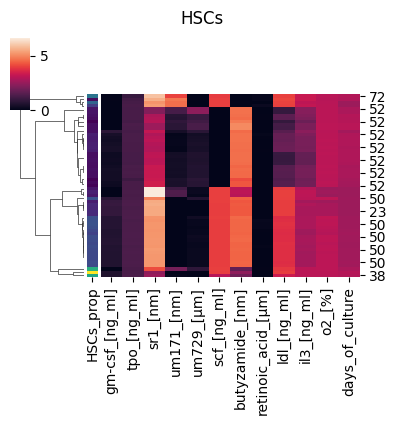

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


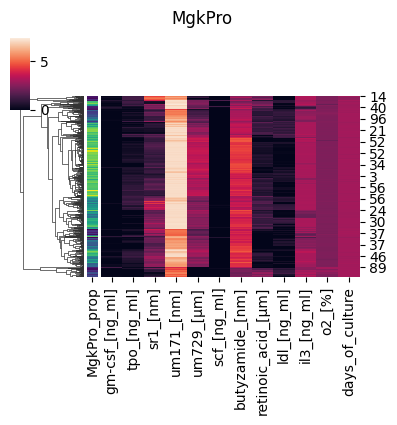

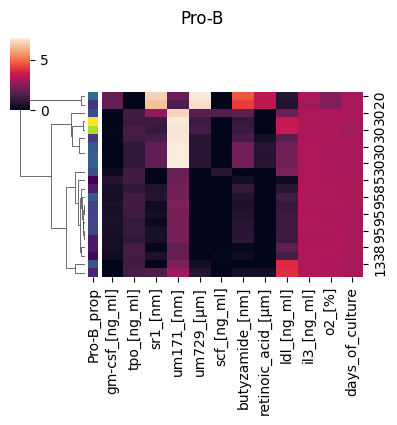

In [14]:
for cell_type in filtered_df:
    cell_type_safe_revert = cell_type.replace(":", "/")
    data = np.log1p(filtered_df[cell_type].loc[:, protocol_cols])
    
    # Get the annotation column
    prop_col = filtered_df[cell_type][f"{cell_type_safe_revert}_prop"]
    
    # Normalize + map to colors
    norm = plt.Normalize(prop_col.min(), prop_col.max())
    cmap = plt.cm.viridis
    row_colors = prop_col.map(lambda x: cmap(norm(x)))
    
    g = sns.clustermap(
        data,
        figsize=(4, 4),
        row_cluster=True,
        col_cluster=False,
        row_colors=row_colors  # <-- side annotation here
    )
    
    g.fig.suptitle(cell_type, y=1.05)
    plt.show()

## Check these protocols in the real data 

In [15]:
protocol_adata_real = sc.read_h5ad("protocol_adata.h5ad")

pDCs_cDCs


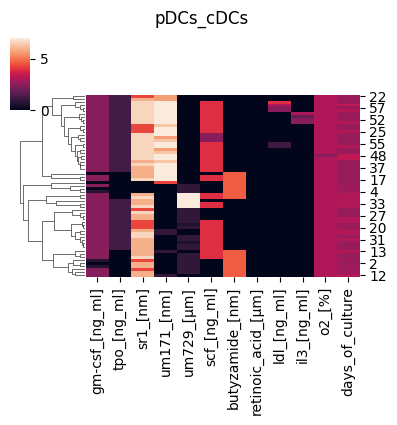

CyclingProgenitor*


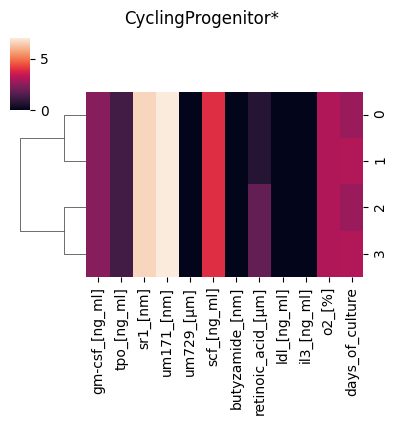

EosBasoMastPre_2


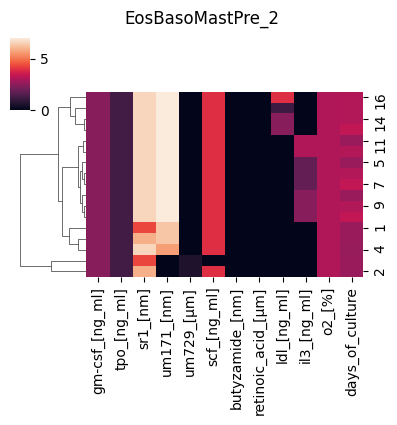

CD49c-Myeloid


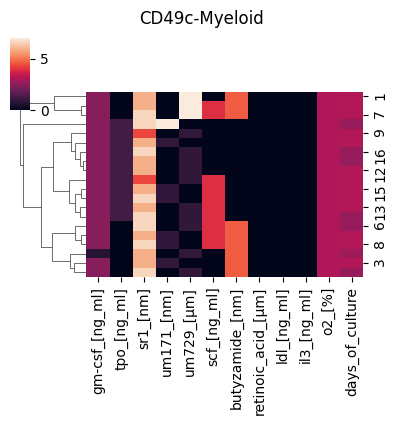

MLP


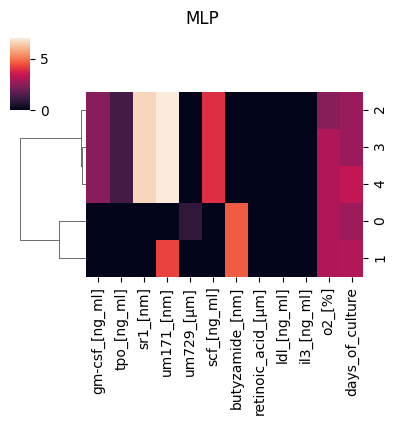

GMP-Cycle


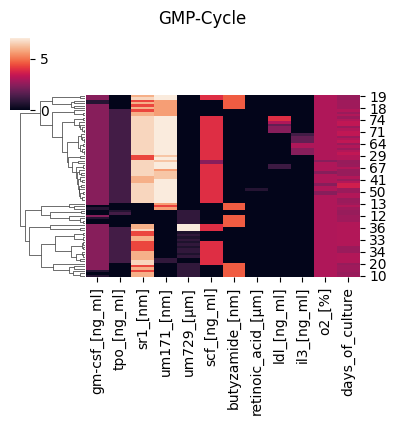

EosBasoMastPre


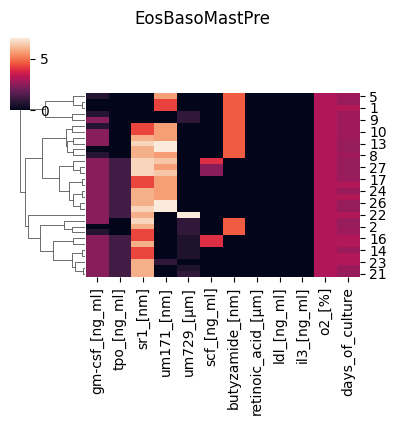

MEP


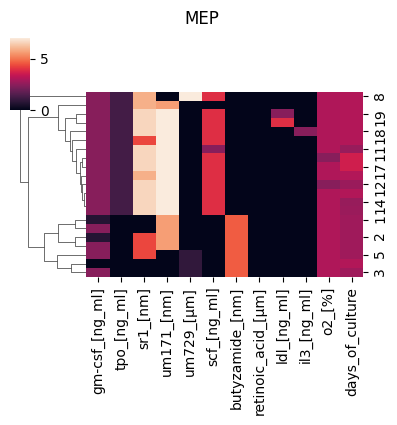

EryPro


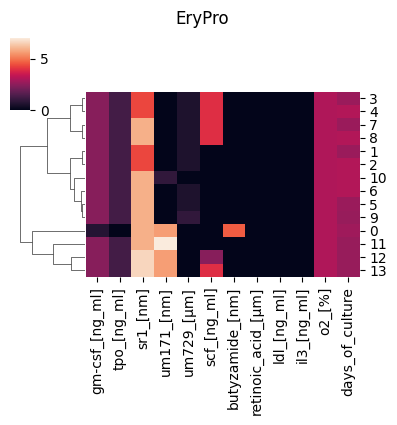

MgkPro
GMP-Neutro


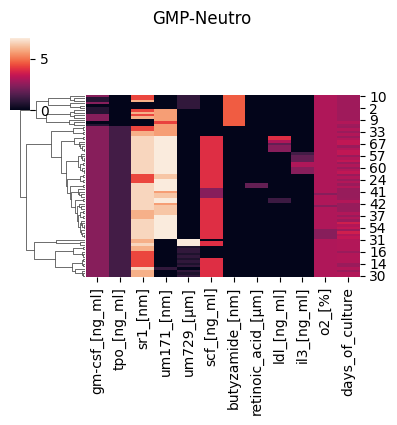

MPP


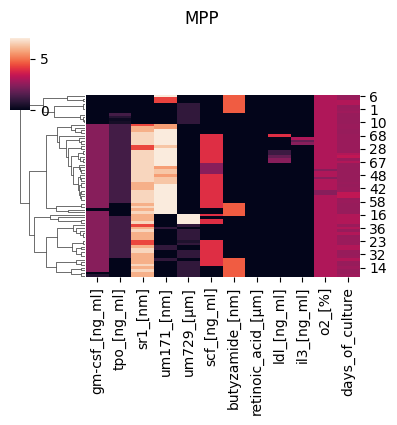

CD14-Mono


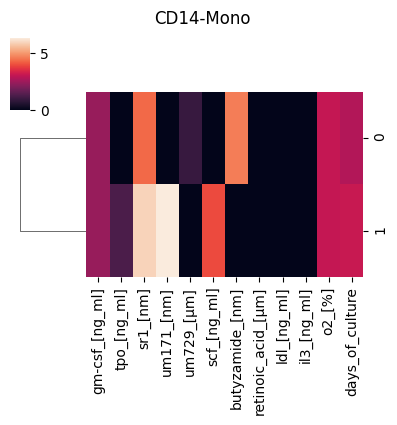

GMP-Neutro_CD16-Mono
EarlyGMP
HSCs


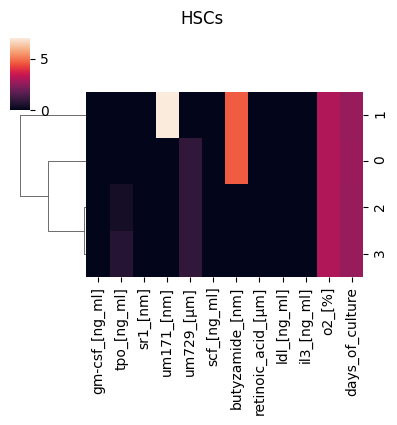

Early_Pro-B
DCs-CD14
Pro-B


In [19]:
for cell_type in protocol_adata_real.obs.columns:
    print(cell_type)
    cell_type_safe_revert = cell_type.replace(":", "_")
    if protocol_adata_real.obs[cell_type_safe_revert].max()>0.10:
        obs_cell_type = protocol_adata_real[protocol_adata_real.obs[cell_type]>0.10]
        obs_cell_type_X = pd.DataFrame(obs_cell_type.X, columns=obs_cell_type.var.index)
        if obs_cell_type_X.shape[0] < 2:
            continue
        obs_cell_type_X = obs_cell_type_X.drop(columns=["740-yp_[µm]", "mtg_[µm]", "rhflt3l_[ng_ml]"])
    
        g = sns.clustermap(
            obs_cell_type_X,
            figsize=(4, 4),
            row_cluster=True,
            col_cluster=False,
        )
    
        g.fig.suptitle(cell_type, y=1.05)
        plt.show()